In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir("/content/drive/MyDrive")

['VID-20240420-WA0010.mp4',
 'video_20240417_200104.mp4',
 'video_20240417_200045.mp4',
 'VID-20240411-WA0066.mp4',
 'VID-20240411-WA0065.mp4',
 'VID-20240411-WA0064.mp4',
 'VID-20240411-WA0063.mp4',
 'VID-20240411-WA0062.mp4',
 'VID-20240411-WA0061.mp4',
 'VID-20240411-WA0060.mp4',
 'VID-20240411-WA0059.mp4',
 'VID-20240411-WA0058.mp4',
 'VID-20240411-WA0057.mp4',
 'VID-20240411-WA0055.mp4',
 'VID-20240411-WA0054.mp4',
 'VID-20240411-WA0053.mp4',
 'VID-20240411-WA0052.mp4',
 'VID_22331119_012447_572.mp4',
 'VID_22130525_030004_072.mp4',
 'video_20240410_174849.mp4',
 'video_20240410_174311.mp4',
 'video_20240410_153748.mp4',
 'video_20240410_153431.mp4',
 'VID-20240303-WA0010.mp4',
 'video_20240115_101230.mp4',
 'video_20240115_101203.mp4',
 'video_20240115_101135.mp4',
 'video_20240115_101121.mp4',
 'VID-20231123-WA0002.mp4',
 'video_20240109_185337.mp4',
 'VID-20231223-WA0001.mp4',
 'video_20230927_163707.mp4',
 'VID-20230927-WA0078.mp4',
 'VID-20230927-WA0071.mp4',
 'VID-20230927-W

In [3]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AISH/instrument_model.h5")

print("Model loaded successfully")

Model loaded successfully


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,061 (12.61 MB)

 Trainable params: 3,306,059 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AISH/instrument_model.h5")


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [5]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    "/content/drive/MyDrive/AISH/dataset_split/test",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 1010 images belonging to 11 classes.


In [ ]:
model.evaluate(test_data)

32/32 ━━━━━━━━━━━━━━━━━━━━ 516s 16s/step - accuracy: 0.5455 - loss: 1.9316


[1.9315978288650513, 0.5455445647239685]

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step


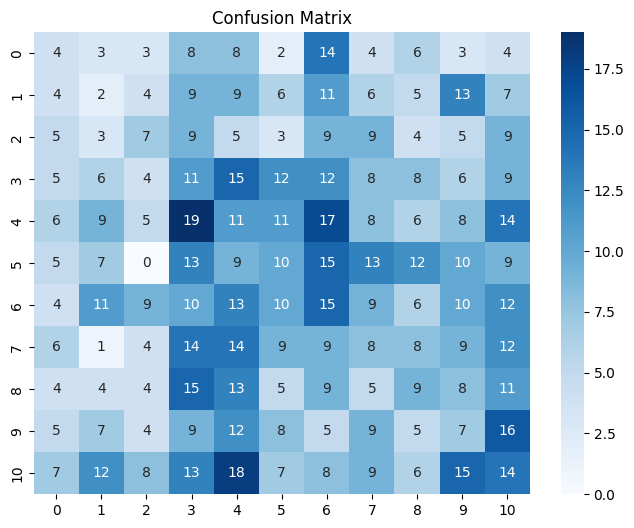

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(test_data)

y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.07      0.07        59
           1       0.03      0.03      0.03        76
           2       0.13      0.10      0.12        68
           3       0.08      0.11      0.10        96
           4       0.09      0.10      0.09       114
           5       0.12      0.10      0.11       103
           6       0.12      0.14      0.13       109
           7       0.09      0.09      0.09        94
           8       0.12      0.10      0.11        87
           9       0.07      0.08      0.08        87
          10       0.12      0.12      0.12       117

    accuracy                           0.10      1010
   macro avg       0.10      0.09      0.09      1010
weighted avg       0.10      0.10      0.10      1010



In [6]:
import cv2
import numpy as np

path = "/content/drive/MyDrive/AISH/dataset_split/test/pia/pia_[pia][cla]1283__3.png"

img = cv2.imread(path)

if img is None:
    print("Image not found. Check file path.")
else:
    img = cv2.resize(img,(128,128))
    img = img/255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[4.5710967e-06 1.1997566e-01 2.6184058e-05 4.7041084e-07 5.4057722e-04
  1.8179817e-09 7.3474450e-03 8.7200832e-01 9.6238306e-05 3.9698833e-07
  2.1083176e-08]]


In [8]:
print(test_data.class_indices)

{'cel': 0, 'cla': 1, 'flu': 2, 'gac': 3, 'gel': 4, 'org': 5, 'pia': 6, 'sax': 7, 'tru': 8, 'vio': 9, 'voi': 10}


In [7]:
classes = list(test_data.class_indices.keys())

print("Predicted:", classes[np.argmax(prediction)])

Predicted: sax


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


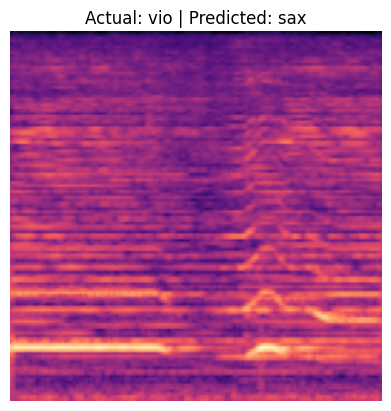

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


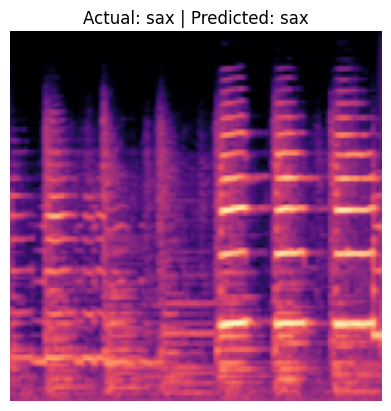

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


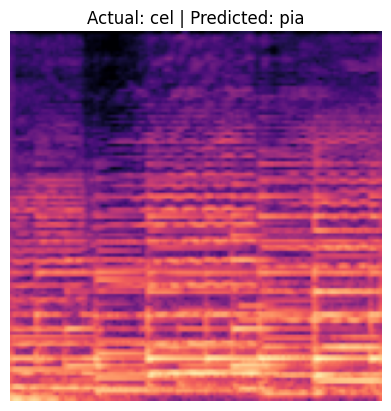

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


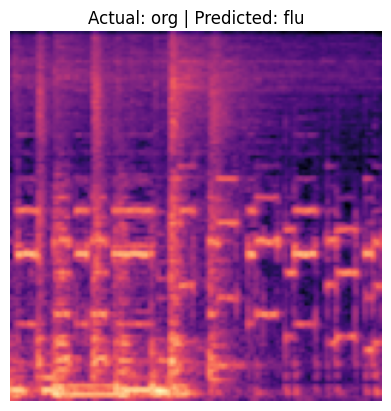

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


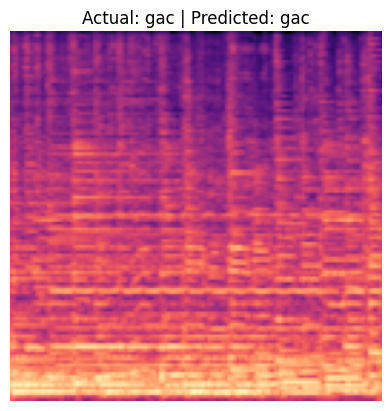

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


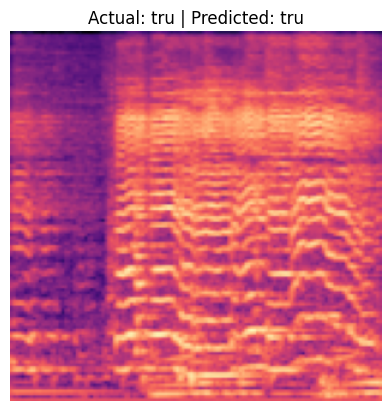

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


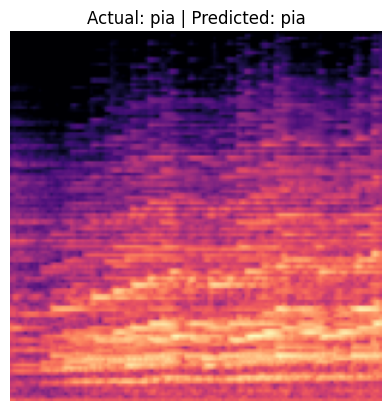

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


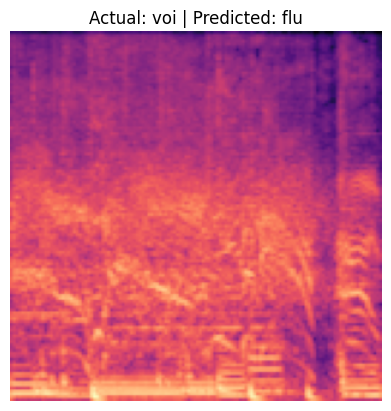

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


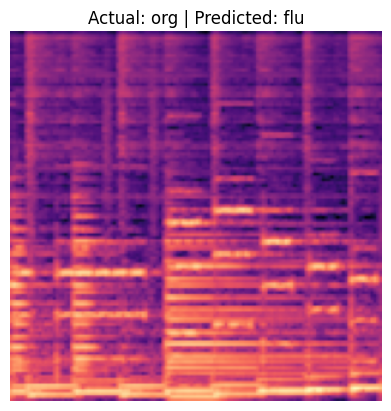

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


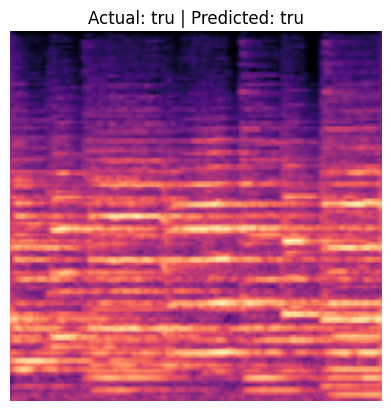

In [10]:
import os
import random
import matplotlib.pyplot as plt

test_folder = "/content/drive/MyDrive/AISH/dataset_split/test"

for i in range(10):

    instrument = random.choice(os.listdir(test_folder))
    img_file = random.choice(os.listdir(test_folder + "/" + instrument))

    path = test_folder + "/" + instrument + "/" + img_file

    img = cv2.imread(path)
    img_resized = cv2.resize(img,(128,128))/255.0
    img_input = np.expand_dims(img_resized, axis=0)

    prediction = model.predict(img_input)
    pred_class = classes[np.argmax(prediction)]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Actual: " + instrument + " | Predicted: " + pred_class)
    plt.axis("off")
    plt.show()